## Prediction of speaker dataset

In [1]:
from preprocessing_class import Preprocessing, load_pres
from sklearn.feature_extraction.text import CountVectorizer,TfidfVectorizer
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.cluster import KMeans
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC,SVC
from nltk.corpus import stopwords
import numpy as np
import string
import matplotlib.pyplot as plt
%load_ext autoreload
%autoreload 2

In [2]:
# load dataset
alltxt, alllabs = load_pres("Dataset/corpus.tache1.learn.utf8")
alltxt, alllabs = np.array(alltxt), np.array(alllabs)

In [3]:
# M = -1, C = 1
len(alltxt), len(alllabs), np.unique(alllabs)

(57413, 57413, array([-1,  1]))

### Split of the dataset

In [4]:
# train test split here for test in final prediction
strat_split = StratifiedShuffleSplit(1, test_size=0.2, random_state=0)

for i, (train_idx, test_idx) in enumerate(strat_split.split(alltxt, alllabs)):
    print(i)
X_train, y_train, X_test, y_test = alltxt[train_idx], alllabs[train_idx], alltxt[test_idx], alllabs[test_idx]

# further split the train 
for i, (train_idx, test_idx) in enumerate(strat_split.split(X_train, y_train)):
    print(i)
X_train_sub, y_train_sub, X_val, y_val = X_train[train_idx], y_train[train_idx], X_train[test_idx], y_train[test_idx]

0
0


In [5]:
len(X_train_sub), len(y_train_sub), len(X_val), len(y_val), len(X_train), len(y_train), len(X_test), len(y_test)

(36744, 36744, 9186, 9186, 45930, 45930, 11483, 11483)

## Experiment 1

Preprocessing:
- lower case
- remove punctuation
- no stemming or lemmatization
- keep all capital words and accents
- language french.

Vectorizer:
- CountVectorizer

Model:
- Logistic Regression

In [6]:
punc = set(string.punctuation + '\n\r\t')
punc.remove("'") # keep the ' for french words 
custom_punctuation = "".join(punc)

prep = Preprocessing(low_case = True,
                rm_punctuation = True,
                rm_number = False,
                word_norm = None, # stem faster
                pos_tagging = False, # to check
                all_capital = True, # keep all capital words as they are
                cap_name = True, # garder les noms en majuscules, for pos tag
                rm_accent = False, 
                lang = "french",
                punct = custom_punctuation, # punctuation can contain -, that would be kept
                urls = False 
                )

In [7]:
# vectorization  
#TODO limit to X vocabulary

final_stopwords_list = stopwords.words('french') # stopwords.words('english') 

def build_vectorizer(name="count", stop_words=None, max_features=None,
                     lowercase=False, strip_accents=None, ngram_range=(1,1), use_idf= True, smooth_idf=True, sublinear_tf=False, 
                     max_df=0.95, min_df=2, preprocessor = lambda x: x):
    if name == "count":
        vectorizer = CountVectorizer(stop_words=stop_words,max_features=max_features,max_df=max_df,min_df=min_df,ngram_range=ngram_range,lowercase=lowercase,
                                     strip_accents=strip_accents, preprocessor=preprocessor)    
        
    elif name == "tfidf":
        vectorizer = TfidfVectorizer(use_idf= use_idf, smooth_idf=smooth_idf, sublinear_tf=sublinear_tf,max_df=max_df, min_df=min_df, max_features=max_features,
                                     stop_words=stop_words, ngram_range=ngram_range,lowercase=lowercase,strip_accents=strip_accents, preprocessor=preprocessor)
    
    return vectorizer
    ## to implement more embeddings 

def build_embeddings():
    pass

def vectorize_txts(txts,vectorizer):
    X = vectorizer.fit_transform(txts)
    return X

In [9]:
# building vectorizer on the train set

vectoriser = build_vectorizer(name="count", stop_words=final_stopwords_list, max_features=None, preprocessor=prep)

# train on the sub train
vectorised_train_sub = vectoriser.fit_transform(X_train_sub)
vectorised_val = vectoriser.transform(X_val)

### Running models

#### On simple split

In [8]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import f1_score
from sklearn.metrics import roc_auc_score
from sklearn.metrics import average_precision_score

## solver = 'newton-cholesky' to try for logistic regression (n_samples >> n_features * n_classes, especially with one-hot encoded categorical features with rare categories)
def build_model(name="kmeans", n_clusters = 2, max_iter = 1000, penalty='l2', loss='squared_hinge',kernel='rbf',solver='lbfgs'):
    if name == "kmeans":
        return KMeans(n_clusters=n_clusters,max_iter=max_iter) 
    elif name == "linear_svm":
        return LinearSVC(penalty=penalty,loss=loss,max_iter=max_iter)
    elif name == "svm":
        return SVC(max_iter=max_iter,kernel=kernel)
    elif name == "logreg":
        return LogisticRegression(solver=solver,max_iter=max_iter) 

def pipeline(model, X_train, y_train, X_test, y_test):
    # fit and preidct Xtrain, Xtest 
    model.fit(X_train,y_train)

    # preds
    y_pred_train = model.predict(X_train)
    ypred_train_prob = model.predict_proba(X_train) # probas for ROC

    y_pred = model.predict(X_test)
    ypred_prob = model.predict_proba(X_test)

    print(f1_score(y_train,y_pred_train),f1_score(y_test,y_pred))
    print(average_precision_score(y_train,y_pred_train), average_precision_score(y_test,y_pred))
    # print(roc_auc_score(y_train, ypred_train_prob), f1_score(y_test,ypred_prob))

    ConfusionMatrixDisplay.from_estimator(model, X_train, y_train)
    plt.show()
    ConfusionMatrixDisplay.from_estimator(model, X_test, y_test)
    plt.show()

    return model

0.9329498525073746 0.9327206315541416
0.881590970267907 0.8802437575250969


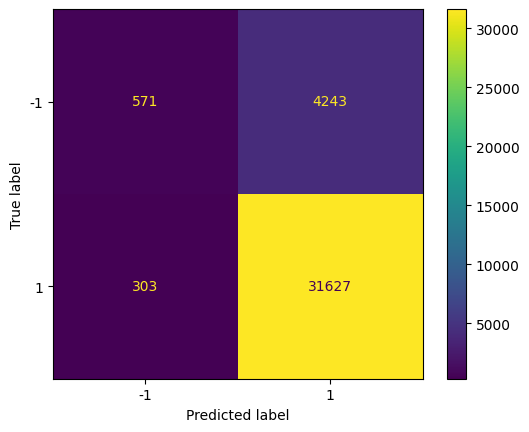

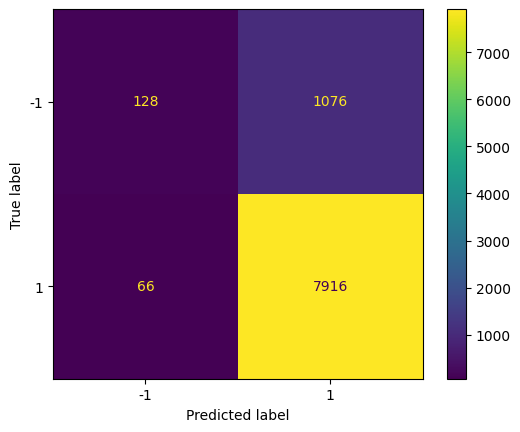

In [105]:
lr = build_model(name="logreg")
lr = pipeline(lr, vectorised_train_sub, y_train_sub, vectorised_val, y_val)

#### Cross validation, then test

In [9]:
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score

# Plot CV train vs validation metrics across folds + test as reference line

def plot(train_cv_metrics, val_cv_metrics, test_metrics):

    metric_names = ["AUC", "F1", "Average Precision", "Recall", "Precision"]
    folds = np.arange(1, len(val_cv_metrics["AUC"]) + 1)

    fig, axes = plt.subplots(1, len(metric_names), figsize=(24, 4), sharex=True)

    for ax, metric_name in zip(axes, metric_names):
        train_vals = train_cv_metrics[metric_name]
        val_vals = val_cv_metrics[metric_name]
        test_val = test_metrics[metric_name]

        ax.plot(folds, train_vals, marker="o", label="Train CV")
        ax.plot(folds, val_vals, marker="o", label="Validation CV")
        ax.axhline(test_val, linestyle="--", linewidth=2, label="Test")

        ax.set_title(metric_name)
        ax.set_xlabel("Fold")
        ax.set_xticks(folds)
        ax.grid(alpha=0.25)

    axes[0].set_ylabel("Score")
    handles, labels = axes[-1].get_legend_handles_labels()
    fig.legend(handles, labels, loc="upper center", ncol=3)
    plt.suptitle("Cross-validation metrics (Train vs Validation) with Test reference", y=1.12)
    plt.tight_layout()
    plt.legend()
    plt.show()

def cv_train(model, kwargs, vect_kwargs, X_train, y_train, X_test, y_test, cv=5, test_size=0.2):
    # split in train val, do a cross validation, then evaluate on the final test set
    # takes in untrained model

    train_cv_metrics = {
        "AUC": [],
        "F1": [],
        "Average Precision": [],
        "Recall": [],
        "Precision": [],
    }

    val_cv_metrics = {
        "AUC": [],
        "F1": [],
        "Average Precision": [],
        "Recall": [],
        "Precision": [],
    }

    # splits
    cv_splits = StratifiedShuffleSplit(cv, test_size=test_size, random_state=0)
    for i, (train_idx, test_idx) in enumerate(cv_splits.split(X_train, y_train)):
        print("Fold ", i)
        X_train_sub, y_train_sub, X_val, y_val = X_train[train_idx], y_train[train_idx], X_train[test_idx], y_train[test_idx]

        # vectorising
        vectoriser = build_vectorizer(**vect_kwargs)

        # train on the sub train
        vect_train_sub = vectoriser.fit_transform(X_train_sub)
        vect_val = vectoriser.transform(X_val)

        clf = model(**kwargs)
        clf.fit(vect_train_sub, y_train_sub)

        # predictions
        y_pred_train = clf.predict(vect_train_sub)
        ypred_train_prob = clf.predict_proba(vect_train_sub)[:, 1]  # probas for ROC

        y_pred = clf.predict(vect_val)
        ypred_prob = clf.predict_proba(vect_val)[:, 1]

        # evaluation
        f1_train, f1_val = f1_score(y_train_sub, y_pred_train), f1_score(y_val, y_pred)
        ap_train, ap_val = average_precision_score(y_train_sub, y_pred_train), average_precision_score(y_val, y_pred)
        auc_train, auc_val = roc_auc_score(y_train_sub, ypred_train_prob), roc_auc_score(y_val, ypred_prob)
        prec_train, prec_val = precision_score(y_train_sub, y_pred_train), precision_score(y_val, y_pred)
        rec_train, rec_val = recall_score(y_train_sub, y_pred_train), recall_score(y_val, y_pred)

        train_cv_metrics["AUC"].append(auc_train)
        train_cv_metrics["F1"].append(f1_train)
        train_cv_metrics["Average Precision"].append(ap_train)
        train_cv_metrics["Recall"].append(rec_train)
        train_cv_metrics["Precision"].append(prec_train)

        val_cv_metrics["AUC"].append(auc_val)
        val_cv_metrics["F1"].append(f1_val)
        val_cv_metrics["Average Precision"].append(ap_val)
        val_cv_metrics["Recall"].append(rec_val)
        val_cv_metrics["Precision"].append(prec_val)

    # final test evaluation
    vectoriser = build_vectorizer(**vect_kwargs)

    vect_train = vectoriser.fit_transform(X_train)
    vect_test = vectoriser.transform(X_test)

    clf = model(**kwargs)
    clf.fit(vect_train, y_train)

    y_pred_train = clf.predict(vect_train)
    ypred_train_prob = clf.predict_proba(vect_train)[:, 1]  # probas for ROC

    y_pred = clf.predict(vect_test)
    ypred_prob = clf.predict_proba(vect_test)[:, 1]

    f1_train, f1_test = f1_score(y_train, y_pred_train), f1_score(y_test, y_pred)
    ap_train, ap_test = average_precision_score(y_train, y_pred_train), average_precision_score(y_test, y_pred)
    auc_train, auc_test = roc_auc_score(y_train, ypred_train_prob), roc_auc_score(y_test, ypred_prob)
    prec_train, prec_test = precision_score(y_train, y_pred_train), precision_score(y_test, y_pred)
    rec_train, rec_test = recall_score(y_train, y_pred_train), recall_score(y_test, y_pred)

    final_train_metrics = {
        "AUC": auc_train,
        "F1": f1_train,
        "Average Precision": ap_train,
        "Recall": rec_train,
        "Precision": prec_train,
    }

    test_metrics = {
        "AUC": auc_test,
        "F1": f1_test,
        "Average Precision": ap_test,
        "Recall": rec_test,
        "Precision": prec_test,
    }

    # print summary
    print("Final Train Results:")
    for metric_name, metric_value in final_train_metrics.items():
        print(f"{metric_name}: {metric_value}")

    print("\nFinal Test Results:")
    for metric_name, metric_value in test_metrics.items():
        print(f"{metric_name}: {metric_value}")

    plot(train_cv_metrics, val_cv_metrics, test_metrics)

Fold  0
Fold  1
Fold  2
Fold  3
Fold  4
Final Train Results:
AUC: 0.736157413957766
F1: 0.9329732152334674
Average Precision: 0.8812697055945661
Recall: 0.9909801563439568
Precision: 0.8813816155988858

Final Test Results:
AUC: 0.7349114230709555
F1: 0.9327544712377897
Average Precision: 0.8812691298536856
Recall: 0.990479053918621
Precision: 0.881387675020066


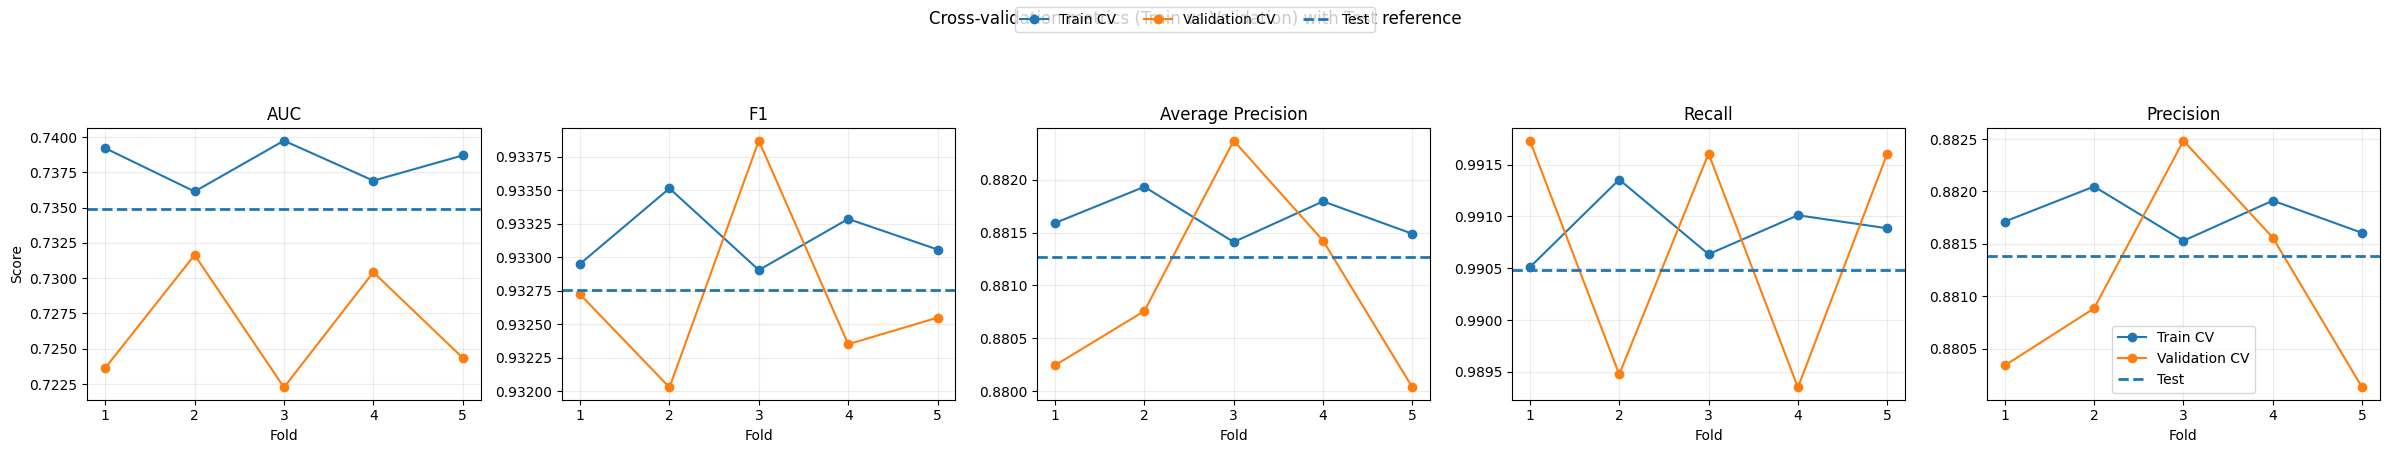

In [144]:
cv_train(LogisticRegression,
    {"solver": "lbfgs", "max_iter": 1000}, 
    {"name":"count", "stop_words":final_stopwords_list, "max_features":None, "preprocessor":prep},
    X_train,
    y_train,
    X_test,
    y_test,
    cv=5,
    test_size=0.2)

#### Model on final train and test 

In [10]:
def eval_test(model, kwargs, vect_kwargs, X_train, y_train, X_test, y_test):
    # vectorising
    vectorizer = build_vectorizer(**vect_kwargs)
    vect_train = vectorizer.fit_transform(X_train)
    vect_test = vectorizer.transform(X_test)

    clf = model(**kwargs)
    clf.fit(vect_train, y_train)

    y_pred_train = clf.predict(vect_train)
    ypred_train_prob = clf.predict_proba(vect_train)[:, 1]  # probas for ROC

    y_pred = clf.predict(vect_test)
    ypred_prob = clf.predict_proba(vect_test)[:, 1]

    f1_train, f1_test = f1_score(y_train, y_pred_train), f1_score(y_test, y_pred)
    ap_train, ap_test = average_precision_score(y_train, y_pred_train), average_precision_score(y_test, y_pred)
    auc_train, auc_test = roc_auc_score(y_train, ypred_train_prob), roc_auc_score(y_test, ypred_prob)
    prec_train, prec_test = precision_score(y_train, y_pred_train), precision_score(y_test, y_pred)
    rec_train, rec_test = recall_score(y_train, y_pred_train), recall_score(y_test, y_pred)

    final_train_metrics = {
        "AUC": auc_train,
        "F1": f1_train,
        "Average Precision": ap_train,
        "Recall": rec_train,
        "Precision": prec_train,
    }

    test_metrics = {
        "AUC": auc_test,
        "F1": f1_test,
        "Average Precision": ap_test,
        "Recall": rec_test,
        "Precision": prec_test,
    }

    # print summary
    print("Final Train Results:")
    for metric_name, metric_value in final_train_metrics.items():
        print(f"{metric_name}: {metric_value}")

    print("\nFinal Test Results:")
    for metric_name, metric_value in test_metrics.items():
        print(f"{metric_name}: {metric_value}")

In [154]:
eval_test(LogisticRegression,
    {"solver": "lbfgs", "max_iter": 1000},
    {"name":"count", "stop_words":final_stopwords_list, "max_features":None, "preprocessor":prep},
    X_train,
    y_train,
    X_test,
    y_test,)

Final Train Results:
AUC: 0.736157413957766
F1: 0.9329732152334674
Average Precision: 0.8812697055945661
Recall: 0.9909801563439568
Precision: 0.8813816155988858

Final Test Results:
AUC: 0.7349114230709555
F1: 0.9327544712377897
Average Precision: 0.8812691298536856
Recall: 0.990479053918621
Precision: 0.881387675020066


## Experiment 2

Preprocessing:
- lower case
- remove punctuation
- no stemming or lemmatization
- keep all capital words and accents
- language french.

Vectorizer:
- TfidfVectorizer

Model:
- Logistic Regression

Fold  0
Fold  1
Fold  2
Fold  3
Fold  4
Final Train Results:
AUC: 0.7314232679458784
F1: 0.9317057154248458
Average Precision: 0.8756686900695206
Recall: 0.9953648025656444
Precision: 0.8756998633337741

Final Test Results:
AUC: 0.7253776247944814
F1: 0.9317254000281545
Average Precision: 0.8759902419296897
Recall: 0.9949889757466426
Precision: 0.8760257654636902


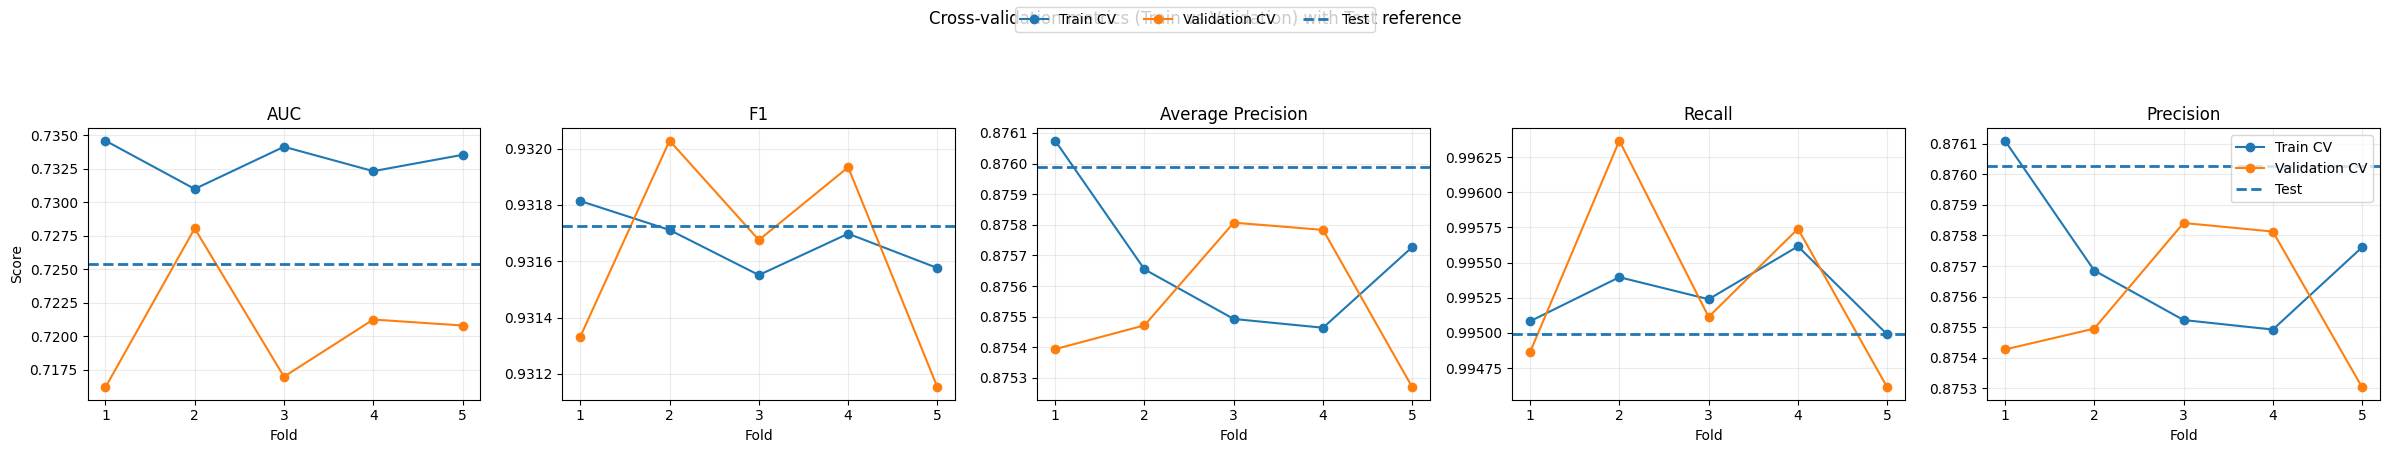

In [152]:
cv_train(LogisticRegression,
    {"solver": "lbfgs", "max_iter": 1000},
    {"name":"tfidf", "stop_words":final_stopwords_list, "max_features":None, "preprocessor":prep},
    X_train,
    y_train,
    X_test,
    y_test,
    cv=5,
    test_size=0.2)

In [25]:
eval_test(LogisticRegression,
    {"solver": "lbfgs", "max_iter": 1000},
    {"name":"tfidf", "stop_words":final_stopwords_list, "max_features":None, "preprocessor":prep},
    X_train,
    y_train,
    X_test,
    y_test,)

Final Train Results:
AUC: 0.7314232679458784
F1: 0.9317057154248458
Average Precision: 0.8756686900695206
Recall: 0.9953648025656444
Precision: 0.8756998633337741

Final Test Results:
AUC: 0.7253776247944814
F1: 0.9317254000281545
Average Precision: 0.8759902419296897
Recall: 0.9949889757466426
Precision: 0.8760257654636902


In [11]:
# with scaling !!
from sklearn import preprocessing

def eval_test(model, kwargs, vect_kwargs, X_train, y_train, X_test, y_test):
    # vectorising
    vectorizer = build_vectorizer(**vect_kwargs)
    vect_train = vectorizer.fit_transform(X_train)
    vect_test = vectorizer.transform(X_test)

    # scaling
    scaler = preprocessing.StandardScaler(with_mean=False).fit(vect_train) # avoid dense matrix
    X_train_scaled = scaler.transform(vect_train)
    X_test_scaled = scaler.transform(vect_test)

    clf = model(**kwargs)
    clf.fit(X_train_scaled, y_train)

    y_pred_train = clf.predict(X_train_scaled)
    ypred_train_prob = clf.predict_proba(X_train_scaled)[:, 1]  # probas for ROC

    y_pred = clf.predict(X_test_scaled)
    ypred_prob = clf.predict_proba(X_test_scaled)[:, 1]

    f1_train, f1_test = f1_score(y_train, y_pred_train), f1_score(y_test, y_pred)
    ap_train, ap_test = average_precision_score(y_train, y_pred_train), average_precision_score(y_test, y_pred)
    auc_train, auc_test = roc_auc_score(y_train, ypred_train_prob), roc_auc_score(y_test, ypred_prob)
    prec_train, prec_test = precision_score(y_train, y_pred_train), precision_score(y_test, y_pred)
    rec_train, rec_test = recall_score(y_train, y_pred_train), recall_score(y_test, y_pred)

    final_train_metrics = {
        "AUC": auc_train,
        "F1": f1_train,
        "Average Precision": ap_train,
        "Recall": rec_train,
        "Precision": prec_train,
    }

    test_metrics = {
        "AUC": auc_test,
        "F1": f1_test,
        "Average Precision": ap_test,
        "Recall": rec_test,
        "Precision": prec_test,
    }

    # print summary
    print("Final Train Results:")
    for metric_name, metric_value in final_train_metrics.items():
        print(f"{metric_name}: {metric_value}")

    print("\nFinal Test Results:")
    for metric_name, metric_value in test_metrics.items():
        print(f"{metric_name}: {metric_value}")

In [29]:
eval_test(LogisticRegression,
    {"solver": "lbfgs", "max_iter": 1000},
    {"name":"tfidf", "stop_words":final_stopwords_list, "max_features":None, "preprocessor":prep},
    X_train,
    y_train,
    X_test,
    y_test,)

Final Train Results:
AUC: 0.7322972828357981
F1: 0.9317698980011033
Average Precision: 0.87645187554095
Recall: 0.9944878733213068
Precision: 0.876493320083913

Final Test Results:
AUC: 0.726290663379701
F1: 0.9317242674680691
Average Precision: 0.876524702201707
Recall: 0.9942874323511726
Precision: 0.8765682982859162


## Experiment 3

Preprocessing:
- lower case
- remove punctuation
- stemming 
- keep all capital words and accents
- language french
- remove numbers

Vectorizer:
- Tfidf

Model:
- Logistic Regression

In [7]:
prep = Preprocessing(low_case = True,
                rm_punctuation = True,
                rm_number = False,
                word_norm = "stem", # stem faster
                pos_tagging = False, # to check
                all_capital = True, # keep all capital words as they are
                cap_name = True, # garder les noms en majuscules, for pos tag
                rm_accent = False, 
                lang = "french",
                punct = custom_punctuation, # punctuation can contain -, that would be kept
                urls = False 
                )

In [19]:
from nltk.stem import SnowballStemmer 
stemmer = SnowballStemmer("french")
stemmed_stopwords = [stemmer.stem(word) for word in final_stopwords_list]

Fold  0
Fold  1
Fold  2
Fold  3
Fold  4
Final Train Results:
AUC: 0.7583983325962516
F1: 0.9328802238893723
Average Precision: 0.8788884682090623
Recall: 0.9938614952896372
Precision: 0.8789497008641701

Final Test Results:
AUC: 0.7542736878275061
F1: 0.9316717611098049
Average Precision: 0.8775839989240133
Recall: 0.9927841250751653
Precision: 0.8776468503588198


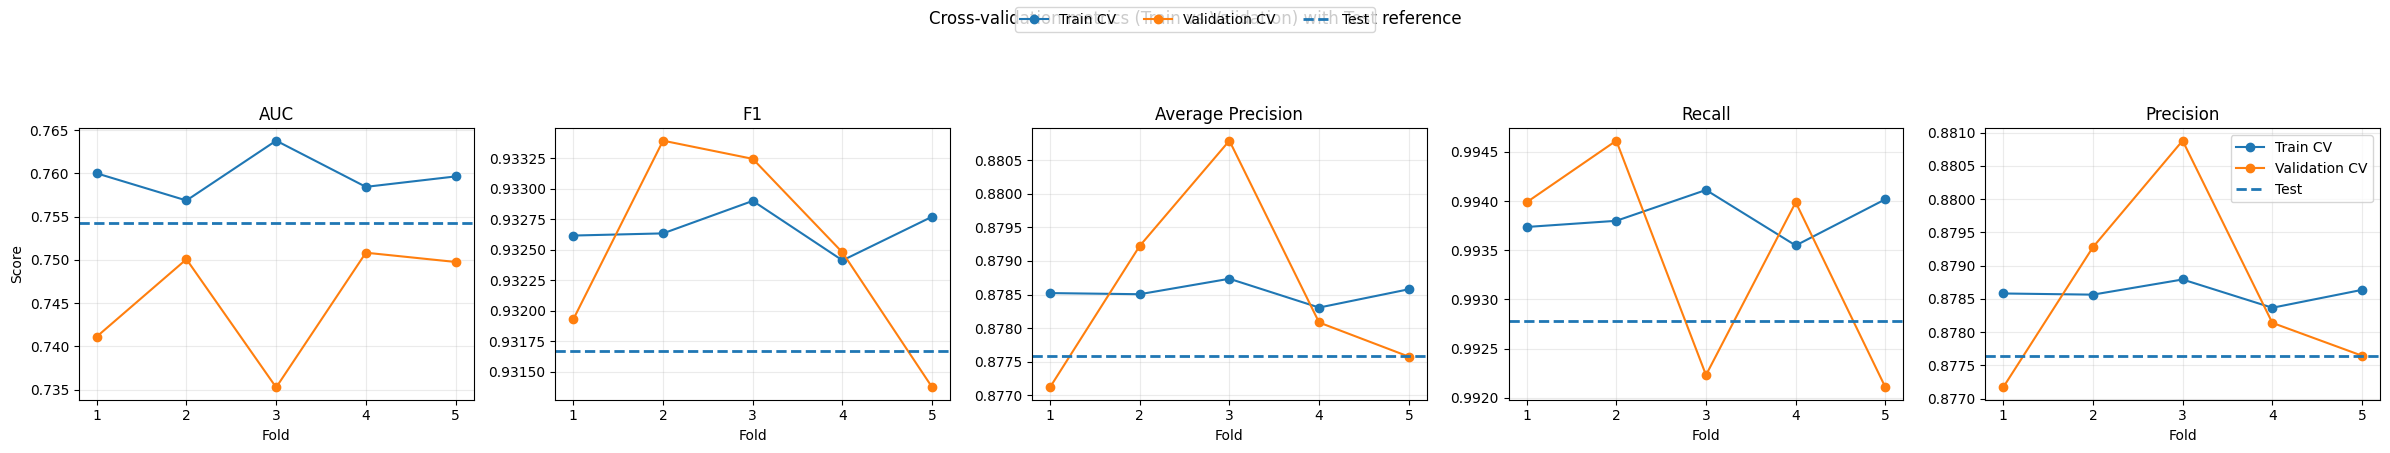

In [20]:
cv_train(LogisticRegression,
    {"solver": "lbfgs", "max_iter": 1000}, 
    {"name":"tfidf", "stop_words":stemmed_stopwords, "max_features":None, "preprocessor":prep},
    X_train,
    y_train,
    X_test,
    y_test,
    cv=5,
    test_size=0.2)

In [21]:
eval_test(LogisticRegression,
    {"solver": "lbfgs", "max_iter": 1000},
    {"name":"tfidf", "stop_words":stemmed_stopwords, "max_features":None, "preprocessor":prep},
    X_train,
    y_train,
    X_test,
    y_test,)

Final Train Results:
AUC: 0.7583983325962516
F1: 0.9328802238893723
Average Precision: 0.8788884682090623
Recall: 0.9938614952896372
Precision: 0.8789497008641701

Final Test Results:
AUC: 0.7542736878275061
F1: 0.9316717611098049
Average Precision: 0.8775839989240133
Recall: 0.9927841250751653
Precision: 0.8776468503588198


## Experiment 4
with lemma

In [27]:
prep = Preprocessing(low_case = True,
                rm_punctuation = True,
                rm_number = False,
                word_norm = "lemma", # stem faster
                pos_tagging = False, # to check
                all_capital = True, # keep all capital words as they are
                cap_name = True, # garder les noms en majuscules, for pos tag
                rm_accent = False, 
                lang = "french",
                punct = custom_punctuation, # punctuation can contain -, that would be kept
                urls = False 
                )

In [25]:
import spacy
NLP_FR = spacy.load("fr_core_news_sm", disable=["parser", "ner"])

lemma_stopwords = []

for word in final_stopwords_list:
    doc = NLP_FR(word)
    for token in doc:
        lemma_stopwords.append(token.lemma_.lower())

Fold  0


/home/franciline/Documents/Master/M1/S2/RITAL/projet_TAL/tal-projet/.venv/lib64/python3.12/site-packages/sklearn/feature_extraction/text.py:411: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ['luir'] not in stop_words.
  warnings.warn(


Fold  1


/home/franciline/Documents/Master/M1/S2/RITAL/projet_TAL/tal-projet/.venv/lib64/python3.12/site-packages/sklearn/feature_extraction/text.py:411: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ['luir'] not in stop_words.
  warnings.warn(


Fold  2


...

Fold  3


/home/franciline/Documents/Master/M1/S2/RITAL/projet_TAL/tal-projet/.venv/lib64/python3.12/site-packages/sklearn/feature_extraction/text.py:411: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ['luir'] not in stop_words.
  warnings.warn(


Fold  4


/home/franciline/Documents/Master/M1/S2/RITAL/projet_TAL/tal-projet/.venv/lib64/python3.12/site-packages/sklearn/feature_extraction/text.py:411: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ['luir'] not in stop_words.
  warnings.warn(
/home/franciline/Documents/Master/M1/S2/RITAL/projet_TAL/tal-projet/.venv/lib64/python3.12/site-packages/sklearn/feature_extraction/text.py:411: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ['luir'] not in stop_words.
  warnings.warn(


Final Train Results:
AUC: 0.7519164940369645
F1: 0.9325631191322149
Average Precision: 0.8789829097834209
Recall: 0.9930096211665664
Precision: 0.8790533646808322

Final Test Results:
AUC: 0.7490304916663837
F1: 0.9316191014410851
Average Precision: 0.8786459419084509
Recall: 0.9912808177991581
Precision: 0.878731343283582


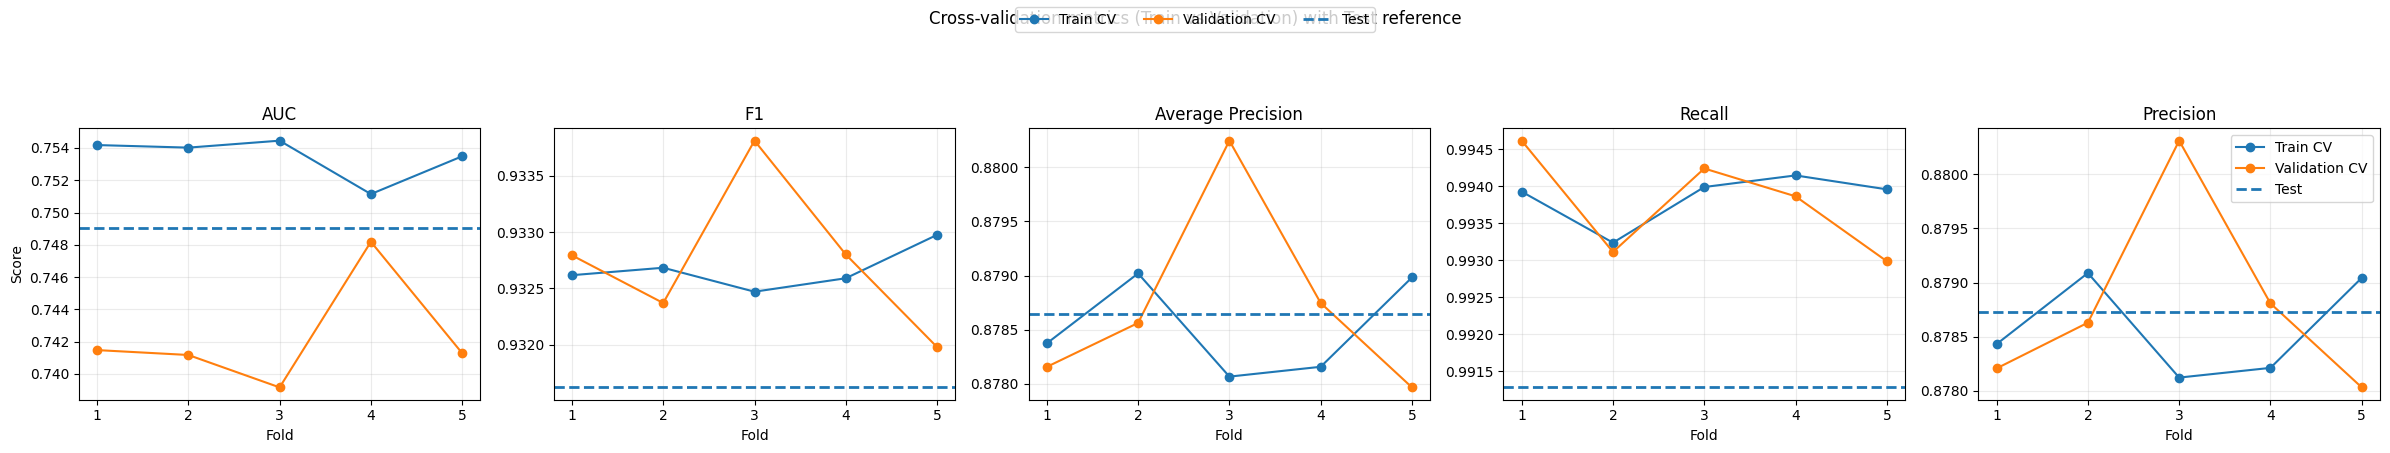

In [28]:
cv_train(LogisticRegression,
    {"solver": "lbfgs", "max_iter": 1000}, 
    {"name":"tfidf", "stop_words":lemma_stopwords, "max_features":None, "preprocessor":prep},
    X_train,
    y_train,
    X_test,
    y_test,
    cv=5,
    test_size=0.2)

In [30]:
eval_test(LogisticRegression,
    {"solver": "lbfgs", "max_iter": 1000},
    {"name":"tfidf", "stop_words":lemma_stopwords, "max_features":None, "preprocessor":prep},
    X_train,
    y_train,
    X_test,
    y_test,)

/home/franciline/Documents/Master/M1/S2/RITAL/projet_TAL/tal-projet/.venv/lib64/python3.12/site-packages/sklearn/feature_extraction/text.py:411: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ['luir'] not in stop_words.
  warnings.warn(


Final Train Results:
AUC: 0.7519164940369645
F1: 0.9325631191322149
Average Precision: 0.8789829097834209
Recall: 0.9930096211665664
Precision: 0.8790533646808322

Final Test Results:
AUC: 0.7490304916663837
F1: 0.9316191014410851
Average Precision: 0.8786459419084509
Recall: 0.9912808177991581
Precision: 0.878731343283582


## Experiment 5

Preprocessing:
- lower case
- remove punctuation
- no stemming or lemmatization
- keep all capital words and accents
- language french
- remove numbers

Vectorizer:
- Embeddings (word2vec)

Model:
- Logistic Regression

In [30]:
prep = Preprocessing(low_case = True,
                rm_punctuation = True,
                rm_number = True,
                word_norm = None, # stem faster
                pos_tagging = False, # to check
                all_capital = True, # keep all capital words as they are
                cap_name = True, # garder les noms en majuscules, for pos tag
                rm_accent = False, 
                lang = "french",
                punct = custom_punctuation, # punctuation can contain -, that would be kept
                urls = False 
                )

In [44]:
import gensim
import logging
logging.basicConfig(format='%(asctime)s : %(levelname)s : %(message)s', level=logging.INFO)

# preprocess train before word2vec
prep_X_train = [prep.process(txt) for txt in X_train]

text = [t.split() for t in prep_X_train] # p is the class

# the following configuration is the default configuration
w2v = gensim.models.word2vec.Word2Vec(sentences=text,
                                vector_size=100, window=5,               ### here we train a cbow model
                                min_count=5,
                                sample=0.001, workers=3,
                                sg=1, hs=0, negative=5,        ### set sg to 1 to train a sg model
                                cbow_mean=1, epochs=5)
# sauvegarder modèle !!!!!
w2v.save("W2v-pres-exp5.dat")
# pour load
# w2v = gensim.models.Word2Vec.load("W2v-pres-exp5.dat")

def embed(text, w2v, mean=False, min = False, max = False):
    """
    This function should vectorize one review

    input: str
    output: np.array(float)
    """ 
    vec = []
    keys = w2v.wv.key_to_index.keys()

    # sum
    for word in text:
        if word in keys:
            idx = w2v.wv.key_to_index[word] 
            vec.append(w2v.wv[idx])
    
    if len(vec) == 0:
        return np.zeros(w2v.vector_size)
    if mean:
        return np.mean(vec, axis = 0)
    if min:
        return np.min(vec, axis = 0)
    if max:
        return np.max(vec, axis = 0)
    return np.sum(vec, axis = 0)


2026-03-14 15:11:33,382 : INFO : collecting all words and their counts
2026-03-14 15:11:33,383 : INFO : PROGRESS: at sentence #0, processed 0 words, keeping 0 word types
2026-03-14 15:11:33,464 : INFO : PROGRESS: at sentence #10000, processed 212951 words, keeping 15560 word types
2026-03-14 15:11:33,547 : INFO : PROGRESS: at sentence #20000, processed 427360 words, keeping 21160 word types
2026-03-14 15:11:33,634 : INFO : PROGRESS: at sentence #30000, processed 642222 words, keeping 25090 word types
2026-03-14 15:11:33,720 : INFO : PROGRESS: at sentence #40000, processed 857679 words, keeping 28172 word types
2026-03-14 15:11:33,766 : INFO : collected 29748 word types from a corpus of 985157 raw words and 45930 sentences
2026-03-14 15:11:33,767 : INFO : Creating a fresh vocabulary
2026-03-14 15:11:33,843 : INFO : Word2Vec lifecycle event {'msg': 'effective_min_count=5 retains 10252 unique words (34.46% of original 29748, drops 19496)', 'datetime': '2026-03-14T15:11:33.843314', 'gensim

In [45]:
prep_X_test = [prep.process(txt) for txt in X_test]

prep_X_train_vect = [embed(text, w2v) for text in prep_X_train]
prep_X_test_vect = [embed(text, w2v) for text in prep_X_test]

In [11]:
from sklearn import preprocessing

def eval_test_vect(model, kwargs, X_train, y_train, X_test, y_test):
    # pass the vectorized train and tes    
    # scaling
    scaler = preprocessing.StandardScaler(with_mean=False).fit(X_train) # avoid dense matrix
    X_train_scaled = scaler.transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    clf = model(**kwargs)
    clf.fit(X_train_scaled, y_train)

    y_pred_train = clf.predict(X_train_scaled)
    ypred_train_prob = clf.predict_proba(X_train_scaled)[:, 1]  # probas for ROC

    y_pred = clf.predict(X_test_scaled)
    ypred_prob = clf.predict_proba(X_test_scaled)[:, 1]

    f1_train, f1_test = f1_score(y_train, y_pred_train), f1_score(y_test, y_pred)
    ap_train, ap_test = average_precision_score(y_train, y_pred_train), average_precision_score(y_test, y_pred)
    auc_train, auc_test = roc_auc_score(y_train, ypred_train_prob), roc_auc_score(y_test, ypred_prob)
    prec_train, prec_test = precision_score(y_train, y_pred_train), precision_score(y_test, y_pred)
    rec_train, rec_test = recall_score(y_train, y_pred_train), recall_score(y_test, y_pred)

    final_train_metrics = {
        "AUC": auc_train,
        "F1": f1_train,
        "Average Precision": ap_train,
        "Recall": rec_train,
        "Precision": prec_train,
    }

    test_metrics = {
        "AUC": auc_test,
        "F1": f1_test,
        "Average Precision": ap_test,
        "Recall": rec_test,
        "Precision": prec_test,
    }

    # print summary
    print("Final Train Results:")
    for metric_name, metric_value in final_train_metrics.items():
        print(f"{metric_name}: {metric_value}")

    print("\nFinal Test Results:")
    for metric_name, metric_value in test_metrics.items():
        print(f"{metric_name}: {metric_value}")

In [48]:
lr = build_model(name="logreg")

eval_test_vect(LogisticRegression,
    {"solver": "lbfgs", "max_iter": 1000},
    prep_X_train_vect,
    y_train,    
    prep_X_test_vect,
    y_test
)

Final Train Results:
AUC: 0.5996053148098965
F1: 0.9298783687653789
Average Precision: 0.8697607088299805
Recall: 0.9989226297855281
Precision: 0.8697615567529833

Final Test Results:
AUC: 0.5862969629530482
F1: 0.9304972478776006
Average Precision: 0.8703310289427719
Recall: 0.9995991180597315
Precision: 0.8703315881326352


## Experiment 6

Preprocessing:
- lower case
- remove punctuation
- no stemming or lemmatization
- keep all capital words and accents
- language french
- remove numbers

Vectorizer:
- Embeddings using embedders

Model:
- Logistic Regression

In [42]:
from sentence_transformers import SentenceTransformer

# Load model (allow custom code)
model = SentenceTransformer(
    "jinaai/jina-embeddings-v5-text-nano",
    trust_remote_code=True
)

# Encode with the task specified
X_train_emb = model.encode(X_train, batch_size=32, show_progress_bar=True, task="retrieval")
X_test_emb = model.encode(X_test, batch_size=32, show_progress_bar=True, task="retrieval")

Fetching 8 files: 100%|██████████| 8/8 [00:00<00:00, 29511.37it/s]
Default prompt name is set to 'document'. This prompt will be applied to all `encode()` calls, except if `encode()` is called with `prompt` or `prompt_name` parameters.
Batches:   0%|          | 0/1436 [00:00<?, ?it/s]/home/franciline/Documents/Master/M1/S2/RITAL/projet_TAL/tal-projet/.venv/lib64/python3.12/site-packages/transformers/modeling_attn_mask_utils.py:202: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
Batches: 100%|██████████| 359/359 [01:34<00:00,  3.80it/s]


In [57]:
eval_test_vect(LogisticRegression,
    {"solver": "lbfgs", "max_iter": 1000},
    X_train_emb,
    y_train,    
    X_test_emb,
    y_test
)

Final Train Results:
AUC: 0.8659724208146591
F1: 0.942427717752158
Average Precision: 0.9084828924810417
Recall: 0.9779765484064943
Precision: 0.9093725974419309

Final Test Results:
AUC: 0.8475847529015662
F1: 0.9373641763654803
Average Precision: 0.9035831418743665
Recall: 0.9726398075766687
Precision: 0.9045577407027682


## Experiment 7 with HMM


In [24]:
prep = Preprocessing(low_case = True,
                rm_punctuation = True,
                rm_number = False,
                word_norm = None, # stem faster
                pos_tagging = False, # to check
                all_capital = True, # keep all capital words as they are
                cap_name = True, # garder les noms en majuscules, for pos tag
                rm_accent = False, 
                lang = "french",
                punct = custom_punctuation, # punctuation can contain -, that would be kept
                urls = False 
                )

In [25]:
# hmm work with count only

vectoriser = build_vectorizer(name="count", stop_words=final_stopwords_list, max_features=2000, preprocessor=prep)

In [26]:
vect_Xtrain = vectoriser.fit_transform(X_train)
vect_Xtest = vectoriser.transform(X_test)

In [27]:
len(vectoriser.vocabulary_)

2000

In [28]:
idx_1 = np.where(y_train == 1)[0]
idx_m1 = np.where(y_train == -1)[0]

In [29]:
from hmmlearn import hmm

# Train Model A classe 1 
model_a = hmm.MultinomialHMM(n_components=3) 
model_a.fit(vect_Xtrain[idx_1].toarray())

MultinomialHMM has undergone major changes. The previous version was implementing a CategoricalHMM (a special case of MultinomialHMM). This new implementation follows the standard definition for a Multinomial distribution (e.g. as in https://en.wikipedia.org/wiki/Multinomial_distribution). See these issues for details:
https://github.com/hmmlearn/hmmlearn/issues/335
https://github.com/hmmlearn/hmmlearn/issues/340


,n_components,3
,n_trials,"array([ 2, 7...hape=(39912,))"
,startprob_prior,1.0
,transmat_prior,1.0
,algorithm,'viterbi'
,random_state,RandomState(M...0x7F514A5C7040
,n_iter,10
,tol,0.01
,verbose,False
,params,'ste'
,init_params,'ste'


In [33]:
# Train Model B
model_b = hmm.MultinomialHMM(n_components=3)
model_b.fit(vect_Xtrain[idx_m1].toarray())

MultinomialHMM has undergone major changes. The previous version was implementing a CategoricalHMM (a special case of MultinomialHMM). This new implementation follows the standard definition for a Multinomial distribution (e.g. as in https://en.wikipedia.org/wiki/Multinomial_distribution). See these issues for details:
https://github.com/hmmlearn/hmmlearn/issues/335
https://github.com/hmmlearn/hmmlearn/issues/340


,n_components,3
,n_trials,"array([11, 7...shape=(6018,))"
,startprob_prior,1.0
,transmat_prior,1.0
,algorithm,'viterbi'
,random_state,RandomState(M...0x7F514A5C7040
,n_iter,10
,tol,0.01
,verbose,False
,params,'ste'
,init_params,'ste'


In [ ]:
pred = []

for el in vect_Xtest:
    score_1 = model_a.score(el.toarray())
    score_m1 = model_b.score(el.toarray())

    logL = np.array([score_1, score_m1])
    probs = np.exp(logL - np.max(logL))  # subtract max for numerical stability
    probs /= probs.sum()
    pred.append(probs)

pred = np.array(pred)

In [39]:
pred_train = []

for el in vect_Xtrain:
    score_1 = model_a.score(el.toarray())
    score_m1 = model_b.score(el.toarray())

    logL = np.array([score_1, score_m1])
    probs = np.exp(logL - np.max(logL))  # subtract max for numerical stability
    probs /= probs.sum()
    pred_train.append(probs)

pred_train = np.array(pred_train)

In [40]:
predictions_train = np.where(pred_train[:, 0] > pred_train[:, 1], 1, -1)
predictions = np.where(pred[:, 0] > pred[:, 1], 1, -1)

In [41]:
f1_train, f1_test = f1_score(y_train, predictions_train), f1_score(y_test, predictions)
ap_train, ap_test = average_precision_score(y_train, predictions_train), average_precision_score(y_test, predictions)
auc_train, auc_test = roc_auc_score(y_train, pred_train[:,0]), roc_auc_score(y_test, pred[:, 0])
prec_train, prec_test = precision_score(y_train, predictions_train), precision_score(y_test, predictions)
rec_train, rec_test = recall_score(y_train, predictions_train), recall_score(y_test, predictions)

In [42]:
print(f1_train, f1_test)
print(ap_train, ap_test)
print(auc_train, auc_test)
print(prec_train, prec_test)
print(rec_train, rec_test)

0.7497689638977684 0.7463680387409201
0.9181343357491336 0.9143096025560696
0.759174995558524 0.7433757588954837
0.9482659513316727 0.9423723631916845
0.6199889757466426 0.6178592904389657
